*Boosting Algo*

In [ ]:
!pip install optuna

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile

zip_path = '/content/drive/MyDrive/dataset.zip'  # change to your path
extract_path = '/content/dataset'                   # where to extract

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")

dataset = pd.read_csv('/content/dataset/dataset.csv')  # change to your file name
print(dataset.shape)
dataset.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted successfully!
(2024108, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,10224738,HY411648,09/05/2015 01:30:00 PM,043XX S WOOD ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,...,12.0,61.0,08B,1165074.0,1875917.0,2015,02/10/2018 03:50:01 PM,41.815117,-87.670000,"(41.815117282, -87.669999562)"
1,10224739,HY411615,09/04/2015 11:30:00 AM,008XX N CENTRAL AVE,0870,THEFT,POCKET-PICKING,CTA BUS,False,False,...,29.0,25.0,06,1138875.0,1904869.0,2015,02/10/2018 03:50:01 PM,41.895080,-87.765400,"(41.895080471, -87.765400451)"
2,10224740,HY411595,09/05/2015 12:45:00 PM,035XX W BARRY AVE,2023,NARCOTICS,POSS: HEROIN(BRN/TAN),SIDEWALK,True,False,...,35.0,21.0,18,1152037.0,1920384.0,2015,02/10/2018 03:50:01 PM,41.937406,-87.716650,"(41.937405765, -87.716649687)"
3,10224741,HY411610,09/05/2015 01:00:00 PM,0000X N LARAMIE AVE,0560,ASSAULT,SIMPLE,APARTMENT,False,True,...,28.0,25.0,08A,1141706.0,1900086.0,2015,02/10/2018 03:50:01 PM,41.881903,-87.755121,"(41.881903443, -87.755121152)"
4,10224742,HY411435,09/05/2015 10:55:00 AM,082XX S LOOMIS BLVD,0610,BURGLARY,FORCIBLE ENTRY,RESIDENCE,False,False,...,21.0,71.0,05,1168430.0,1850165.0,2015,02/10/2018 03:50:01 PM,41.744379,-87.658431,"(41.744378879, -87.658430635)"


In [ ]:
dataset = pd.read_csv('/content/dataset/dataset.csv')  # change to your file name

dataset['Arrest'] = dataset['Arrest'].astype(str).str.lower().map({'true': 1, 'false': 0})
dataset['Domestic'] = dataset['Domestic'].astype(str).str.lower().map({'true': 1, 'false': 0})

dataset['Date']=pd.to_datetime(dataset['Date'],format='%m/%d/%Y %I:%M:%S %p')
dataset['Hour']=dataset['Date'].dt.hour
dataset['day']=dataset['Date'].dt.day
dataset['month']=dataset['Date'].dt.month

dataset.drop(columns=['ID','Case Number','Date','Description','FBI Code','IUCR','X Coordinate','Y Coordinate','Updated On','Location','Block'],inplace=True)

# Option 1: Keep top N most frequent, group rest as "OTHER"
top_locations = dataset['Location Description'].value_counts().nlargest(60).index
dataset['Location Description'] = dataset['Location Description'].apply(
    lambda x: x if x in top_locations else 'OTHER'
)
dataset = pd.get_dummies(dataset, columns=['Location Description'],dtype=int)


"""le = LabelEncoder()
dataset['Primary Type'] = le.fit_transform(dataset['Primary Type'])
class_names = le.classes_
num_classes = dataset['Primary Type'].nunique()
print(f"Number of classes: {num_classes}\n{class_names}")

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

dataset.head()"""

'le = LabelEncoder()\ndataset[\'Primary Type\'] = le.fit_transform(dataset[\'Primary Type\'])\nclass_names = le.classes_\nnum_classes = dataset[\'Primary Type\'].nunique()\nprint(f"Number of classes: {num_classes}\n{class_names}")\n\nmapping = dict(zip(le.classes_, le.transform(le.classes_)))\nprint(mapping)\n\ndataset.head()'

In [ ]:
# Check class counts
from sklearn.utils import resample

class_counts = dataset['Primary Type'].value_counts()
print(class_counts.tail(10))  # see rarest classes

# Remove classes with less than 10 samples (too rare to be useful)
min_samples = 10
valid_classes = class_counts[class_counts >= min_samples].index
dataset = dataset[dataset['Primary Type'].isin(valid_classes)]

print(f"Removed {len(class_counts) - len(valid_classes)} rare classes")
print(f"Remaining classes: {dataset['Primary Type'].nunique()}")

# Re-encode after removing rare classes
le_final = LabelEncoder()
dataset['Primary Type'] = le_final.fit_transform(dataset['Primary Type'])
num_classes = dataset['Primary Type'].nunique()
class_names = le_final.classes_

print(f"num_classes: {num_classes}")

# Now split with stratify safely
x = dataset.drop('Primary Type', axis=1)
y = dataset['Primary Type']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42, stratify=y)
x_train, x_val, y_train, y_val   = train_test_split(x_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

# Sample


Primary Type
15    1272
14    1271
10    1082
4     1057
21     465
20     145
12      87
26      78
23      43
19      25
Name: count, dtype: int64
Removed 0 rare classes
Remaining classes: 33
num_classes: 33
Train classes:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]
Val classes:    [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int

In [ ]:


import numpy as np

x_train_sample, y_train_sample = resample(
    x_train, y_train,
    n_samples=300000,
    random_state=42,
    stratify=y_train
)

print(f"Train classes:  {sorted(y_train.unique())}")
print(f"Val classes:    {sorted(y_val.unique())}")
print(f"Sample classes: {sorted(y_train_sample.unique())}")


def objective(trial):
    params = {
        'objective':        'multi:softmax',
        'num_class':        num_classes,
        'tree_method':      'hist',
        'device':           'cuda',
        'n_estimators':     trial.suggest_int('n_estimators', 100, 300),
        'max_depth':        trial.suggest_int('max_depth', 3, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.05, 0.3),
        'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'gamma':            trial.suggest_float('gamma', 0, 0.3),
    }

    model = XGBClassifier(**params, random_state=42, early_stopping_rounds=10)
    model.fit(
        x_train_sample, y_train_sample,
        eval_set=[(x_train_sample, y_train_sample)],  # use sample instead of x_val
        verbose=False
    )

    y_pred = model.predict(x_val)
    return accuracy_score(y_val, y_pred)

# Run optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)



[I 2026-05-04 20:49:19,178] A new study created in memory with name: no-name-1fbf11bb-ef35-43f8-b955-2f66ddb2d5d1


Train classes:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]
Val classes:    [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]
Sample classes: [np.int64(0), np.int64(1), np.int64(2), np.int

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-04 20:49:42,312] Trial 0 finished with value: 0.4035641078299551 and parameters: {'n_estimators': 127, 'max_depth': 4, 'learning_rate': 0.07883957703512763, 'subsample': 0.8381862140278051, 'colsample_bytree': 0.7627046215873035, 'min_child_weight': 2, 'gamma': 0.07058428514364261}. Best is trial 0 with value: 0.4035641078299551.
[I 2026-05-04 20:50:19,681] Trial 1 finished with value: 0.4163124387285768 and parameters: {'n_estimators': 223, 'max_depth': 5, 'learning_rate': 0.1339680807418332, 'subsample': 0.8938341335385745, 'colsample_bytree': 0.8977532269888796, 'min_child_weight': 2, 'gamma': 0.21213514807368106}. Best is trial 1 with value: 0.4163124387285768.
[I 2026-05-04 20:50:57,798] Trial 2 finished with value: 0.41705641427038087 and parameters: {'n_estimators': 227, 'max_depth': 5, 'learning_rate': 0.2760906046042815, 'subsample': 0.8883521072513504, 'colsample_bytree': 0.9118884471003753, 'min_child_weight': 1, 'gamma': 0.11940855868354425}. Best is trial 2 with

In [ ]:
# Train final model on FULL training data with best params
best_params = study.best_params
final_model = XGBClassifier(
    **best_params,
    objective='multi:softmax',
    num_class=num_classes,
    tree_method='hist',
    device='cuda',
    random_state=42,
    early_stopping_rounds=20
)

final_model.fit(
    x_train, y_train,              # full data this time
    eval_set=[(x_val, y_val)],
    verbose=50
)

# Evaluate on test set
y_pred = final_model.predict(x_test)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))

[0]	validation_0-mlogloss:2.27068
[50]	validation_0-mlogloss:1.78057
[100]	validation_0-mlogloss:1.75684
[150]	validation_0-mlogloss:1.74636
[200]	validation_0-mlogloss:1.73939
[204]	validation_0-mlogloss:1.73880

Test Accuracy: 0.42465153351602025

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TypeError: object of type 'numpy.int64' has no len()

In [ ]:
y_pred_xgb = final_model.predict(x_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

actual_names = le_final.inverse_transform(y_test.values)
pred_xgb_names = le_final.inverse_transform(y_pred_xgb)


xgb_results = pd.DataFrame({
    'Actual': actual_names,
    'Predicted_XGB': pred_xgb_names
})

print("\nXGBoost Results:")
print(xgb_results.head(15))

print("\nXGBoost Accuracy:", xgb_accuracy)


XGBoost Results:
    Actual  Predicted_XGB
0        9             31
1       31             31
2        2             31
3        1             31
4        6             17
5       17             31
6        1              2
7       18             18
8        9              9
9        2              2
10       9              9
11       6              2
12       3              3
13      31              6
14       2              2

XGBoost Accuracy: 0.42465153351602025


In [ ]:
import catboost as cb
from catboost import CatBoostClassifier
import optuna
from sklearn.metrics import accuracy_score
from sklearn.utils import resample

# Sample for tuning
x_train_sample, y_train_sample = resample(
    x_train, y_train,
    n_samples=300000,
    random_state=42,
    stratify=y_train
)

def objective(trial):
    params = {
        'iterations':        trial.suggest_int('iterations', 100, 300),
        'depth':             trial.suggest_int('depth', 3, 6),
        'learning_rate':     trial.suggest_float('learning_rate', 0.05, 0.3),
        'subsample':         trial.suggest_float('subsample', 0.7, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 5),
        'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg', 1, 10),
        'bootstrap_type':    'Bernoulli',
        # colsample_bylevel REMOVED — not supported on GPU
    }

    model = CatBoostClassifier(
        **params,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        task_type='GPU',
        random_seed=42,
        early_stopping_rounds=10,
        verbose=False
    )

    model.fit(
        x_train_sample, y_train_sample,
        eval_set=(x_val, y_val),
    )

    y_pred = model.predict(x_val)
    return accuracy_score(y_val, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2026-05-04 21:14:35,730] A new study created in memory with name: no-name-f494e60a-1dda-440a-b4a0-185cc14a27c3


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-04 21:14:46,116] Trial 0 finished with value: 0.4002898404714945 and parameters: {'iterations': 118, 'depth': 6, 'learning_rate': 0.08198436902827337, 'subsample': 0.9380257849240135, 'min_child_samples': 3, 'l2_leaf_reg': 7.376508856371834}. Best is trial 0 with value: 0.4002898404714945.
[I 2026-05-04 21:14:54,717] Trial 1 finished with value: 0.39669783355872174 and parameters: {'iterations': 149, 'depth': 5, 'learning_rate': 0.06497242475952054, 'subsample': 0.7326611541327253, 'min_child_samples': 3, 'l2_leaf_reg': 3.9771985009325257}. Best is trial 0 with value: 0.4002898404714945.
[I 2026-05-04 21:15:06,433] Trial 2 finished with value: 0.41000802098631006 and parameters: {'iterations': 176, 'depth': 5, 'learning_rate': 0.1713142718206252, 'subsample': 0.914619412784798, 'min_child_samples': 3, 'l2_leaf_reg': 8.582834963025856}. Best is trial 2 with value: 0.41000802098631006.
[I 2026-05-04 21:15:17,082] Trial 3 finished with value: 0.40721036295931773 and parameters:

In [ ]:
# Train final CatBoost model on FULL training data with best params
best_params = study.best_params

final_catboost = CatBoostClassifier(
    **best_params,
    bootstrap_type='Bernoulli',  # required for subsample
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type='GPU',
    random_seed=42,
    early_stopping_rounds=20,
    verbose=50
)

final_catboost.fit(
    x_train, y_train,           # full training data
    eval_set=(x_val, y_val),
)

# Evaluate on test set
y_pred = final_catboost.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")


0:	learn: 0.3573056	test: 0.3574144	best: 0.3574144 (0)	total: 191ms	remaining: 43.5s
50:	learn: 0.4044428	test: 0.4034091	best: 0.4034091 (50)	total: 9.16s	remaining: 32s
100:	learn: 0.4122648	test: 0.4113139	best: 0.4113139 (100)	total: 17.6s	remaining: 22.3s
150:	learn: 0.4164989	test: 0.4152275	best: 0.4152275 (150)	total: 26.7s	remaining: 13.8s
200:	learn: 0.4193859	test: 0.4175950	best: 0.4175989 (199)	total: 35.9s	remaining: 5s
228:	learn: 0.4205368	test: 0.4185599	best: 0.4185831 (225)	total: 40.9s	remaining: 0us
bestTest = 0.4185831141
bestIteration = 225
Shrink model to first 226 iterations.
Test Accuracy: 0.4194673534991568

Classification Report:


In [ ]:
# Clean column names — remove special JSON characters

x_train.columns = x_train.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
x_val.columns   = x_val.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
x_test.columns  = x_test.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
x_train_sample.columns = x_train_sample.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

# Verify
print(x_train.columns.tolist())
# Sample for tuning
x_train_sample, y_train_sample = resample(
    x_train, y_train,
    n_samples=300000,
    random_state=42,
    stratify=y_train
)
import lightgbm as lgb
from lightgbm import LGBMClassifier

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 300),
        'max_depth':        trial.suggest_int('max_depth', 3, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.05, 0.3),
        'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 50),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 100),
    }

    model = LGBMClassifier(
        **params,
        objective='multiclass',
        num_class=num_classes,
        device='gpu',        # remove if no GPU
        random_state=42,
        verbose=-1
    )

    model.fit(
        x_train_sample, y_train_sample,
        eval_set=[(x_val, y_val)],
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(-1)]
    )

    y_pred = model.predict(x_val)
    return accuracy_score(y_val, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

['Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community_Area', 'Year', 'Latitude', 'Longitude', 'Hour', 'day', 'month', 'Location_Description_ABANDONED_BUILDING', 'Location_Description_AIRPORT_TERMINAL_UPPER_LEVEL___SECURE_AREA', 'Location_Description_ALLEY', 'Location_Description_APARTMENT', 'Location_Description_ATHLETIC_CLUB', 'Location_Description_ATM__AUTOMATIC_TELLER_MACHINE_', 'Location_Description_BANK', 'Location_Description_BAR_OR_TAVERN', 'Location_Description_CHA_APARTMENT', 'Location_Description_CHA_PARKING_LOT_GROUNDS', 'Location_Description_CHURCH_SYNAGOGUE_PLACE_OF_WORSHIP', 'Location_Description_COMMERCIAL___BUSINESS_OFFICE', 'Location_Description_CONSTRUCTION_SITE', 'Location_Description_CONVENIENCE_STORE', 'Location_Description_CTA_BUS', 'Location_Description_CTA_BUS_STOP', 'Location_Description_CTA_PLATFORM', 'Location_Description_CTA_STATION', 'Location_Description_CTA_TRAIN', 'Location_Description_CURRENCY_EXCHANGE', 'Location_Description_DEPARTMENT_STORE', 

[I 2026-05-04 21:28:01,042] A new study created in memory with name: no-name-303c5680-b2ef-493d-9baf-79d265ca4f88


  0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 1.76406
[I 2026-05-04 21:38:06,422] Trial 0 finished with value: 0.4180328821689987 and parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.0754231710626073, 'subsample': 0.8767893371885377, 'colsample_bytree': 0.9215069766052837, 'min_child_samples': 23, 'reg_lambda': 3.803415156216961, 'reg_alpha': 0.23065481237889018, 'num_leaves': 69}. Best is trial 0 with value: 0.4180328821689987.
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[256]	valid_0's multi_logloss: 1.77192
[I 2026-05-04 21:43:33,800] Trial 1 finished with value: 0.4156420857664304 and parameters: {'n_estimators': 256, 'max_depth': 3, 'learning_rate': 0.20918040315336656, 'subsample': 0.7517542736801976, 'colsample_bytree': 0.7953413364813948, 'min_child_samples': 14, 'reg_lambda': 9.192399768092193, 'reg_a

KeyboardInterrupt: 

In [ ]:
# Train final LightGBM model on FULL training data with best params
best_params = study.best_params

final_lgbm = LGBMClassifier(
    **best_params,
    objective='multiclass',
    num_class=num_classes,
    device='gpu',
    random_state=42,
    verbose=-1
)

final_lgbm.fit(
    x_train, y_train,           # full training data
    eval_set=[(x_val, y_val)],
    callbacks=[lgb.early_stopping(20), lgb.log_evaluation(50)]
)

# Evaluate on test set
y_pred = final_lgbm.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")


Training until validation scores don't improve for 20 rounds
[50]	valid_0's multi_logloss: 1.79675
[100]	valid_0's multi_logloss: 1.76749
[150]	valid_0's multi_logloss: 1.75545
[200]	valid_0's multi_logloss: 1.74808
[250]	valid_0's multi_logloss: 1.74254
[300]	valid_0's multi_logloss: 1.73822
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 1.73822
Test Accuracy: 0.4242595910623946

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TypeError: object of type 'numpy.int64' has no len()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    cohen_kappa_score,
    matthews_corrcoef
)

# Get the feature names XGBoost was trained on
xgb_features = final_model.get_booster().feature_names

# Rename x_test columns to match XGBoost's expected features
x_test_xgb = x_test.copy()
x_test_xgb.columns = xgb_features

# Now predict with each model using correct column names
y_pred_xgb  = final_model.predict(x_test_xgb)
y_pred_cat  = final_catboost.predict(x_test_xgb).flatten().astype(int)  # catboost is flexible
y_pred_lgbm = final_lgbm.predict(x_test)  # lgbm uses cleaned names already

def evaluate_model(model_name, y_test, y_pred, class_names):
    print(f"\n{'='*60}")
    print(f"  {model_name} Evaluation")
    print(f"{'='*60}")

    # Core metrics
    accuracy  = accuracy_score(y_test, y_pred)
    f1_macro  = f1_score(y_test, y_pred, average='macro')
    f1_weight = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    kappa     = cohen_kappa_score(y_test, y_pred)
    mcc       = matthews_corrcoef(y_test, y_pred)

    print(f"  Accuracy:            {accuracy:.4f}")
    print(f"  F1 (Macro):          {f1_macro:.4f}")
    print(f"  F1 (Weighted):       {f1_weight:.4f}")
    print(f"  Precision (W):       {precision:.4f}")
    print(f"  Recall (W):          {recall:.4f}")
    print(f"  Cohen Kappa:         {kappa:.4f}")
    print(f"  Matthews CC:         {mcc:.4f}")

    # Classification report
    print(f"\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(18, 14))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5
    )
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16)
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {
        'Model':      model_name,
        'Accuracy':   accuracy,
        'F1_Macro':   f1_macro,
        'F1_Weighted':f1_weight,
        'Precision':  precision,
        'Recall':     recall,
        'Kappa':      kappa,
        'MCC':        mcc
    }


# ── Evaluate all three models ──────────────────────────────


xgb_metrics  = evaluate_model("XGBoost",  y_test, y_pred_xgb,  class_names)
cat_metrics  = evaluate_model("CatBoost", y_test, y_pred_cat,  class_names)
lgbm_metrics = evaluate_model("LightGBM", y_test, y_pred_lgbm, class_names)


# ── Side-by-side comparison table ─────────────────────────
comparison = pd.DataFrame([xgb_metrics, cat_metrics, lgbm_metrics])
comparison.set_index('Model', inplace=True)
print("\n========== Models Comparison ==========")
print(comparison.round(4).to_string())

# ── Bar chart comparison ───────────────────────────────────
comparison.drop(columns=['MCC', 'Kappa']).plot(
    kind='bar',
    figsize=(12, 6),
    colormap='Set2',
    edgecolor='black'
)
plt.title('Boosting Models - Performance Comparison', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


  XGBoost Evaluation
  Accuracy:            0.4247
  F1 (Macro):          0.1747
  F1 (Weighted):       0.3698
  Precision (W):       0.3887
  Recall (W):          0.4247
  Cohen Kappa:         0.3202
  Matthews CC:         0.3283

--- Classification Report ---


TypeError: object of type 'numpy.int64' has no len()


  XGBoost Evaluation
  Accuracy:            0.4247
  F1 (Macro):          0.1747
  F1 (Weighted):       0.3698
  Precision (W):       0.3887
  Recall (W):          0.4247
  Cohen Kappa:         0.3202
  Matthews CC:         0.3283

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.23      0.01      0.02       573
           1       0.27      0.01      0.02     24187
           2       0.51      0.64      0.57     57277
           3       0.36      0.38      0.37     12994
           4       0.53      0.30      0.38       159
           5       0.44      0.01      0.01       956
           6       0.26      0.18      0.21     34135
           7       0.56      0.05      0.09       829
           8       0.34      0.20      0.25      6950
           9       0.39      0.47      0.42     19834
          10       0.18      0.02      0.03       162
          11       0.22      0.04      0.07       834
          12       0.00      0.00 

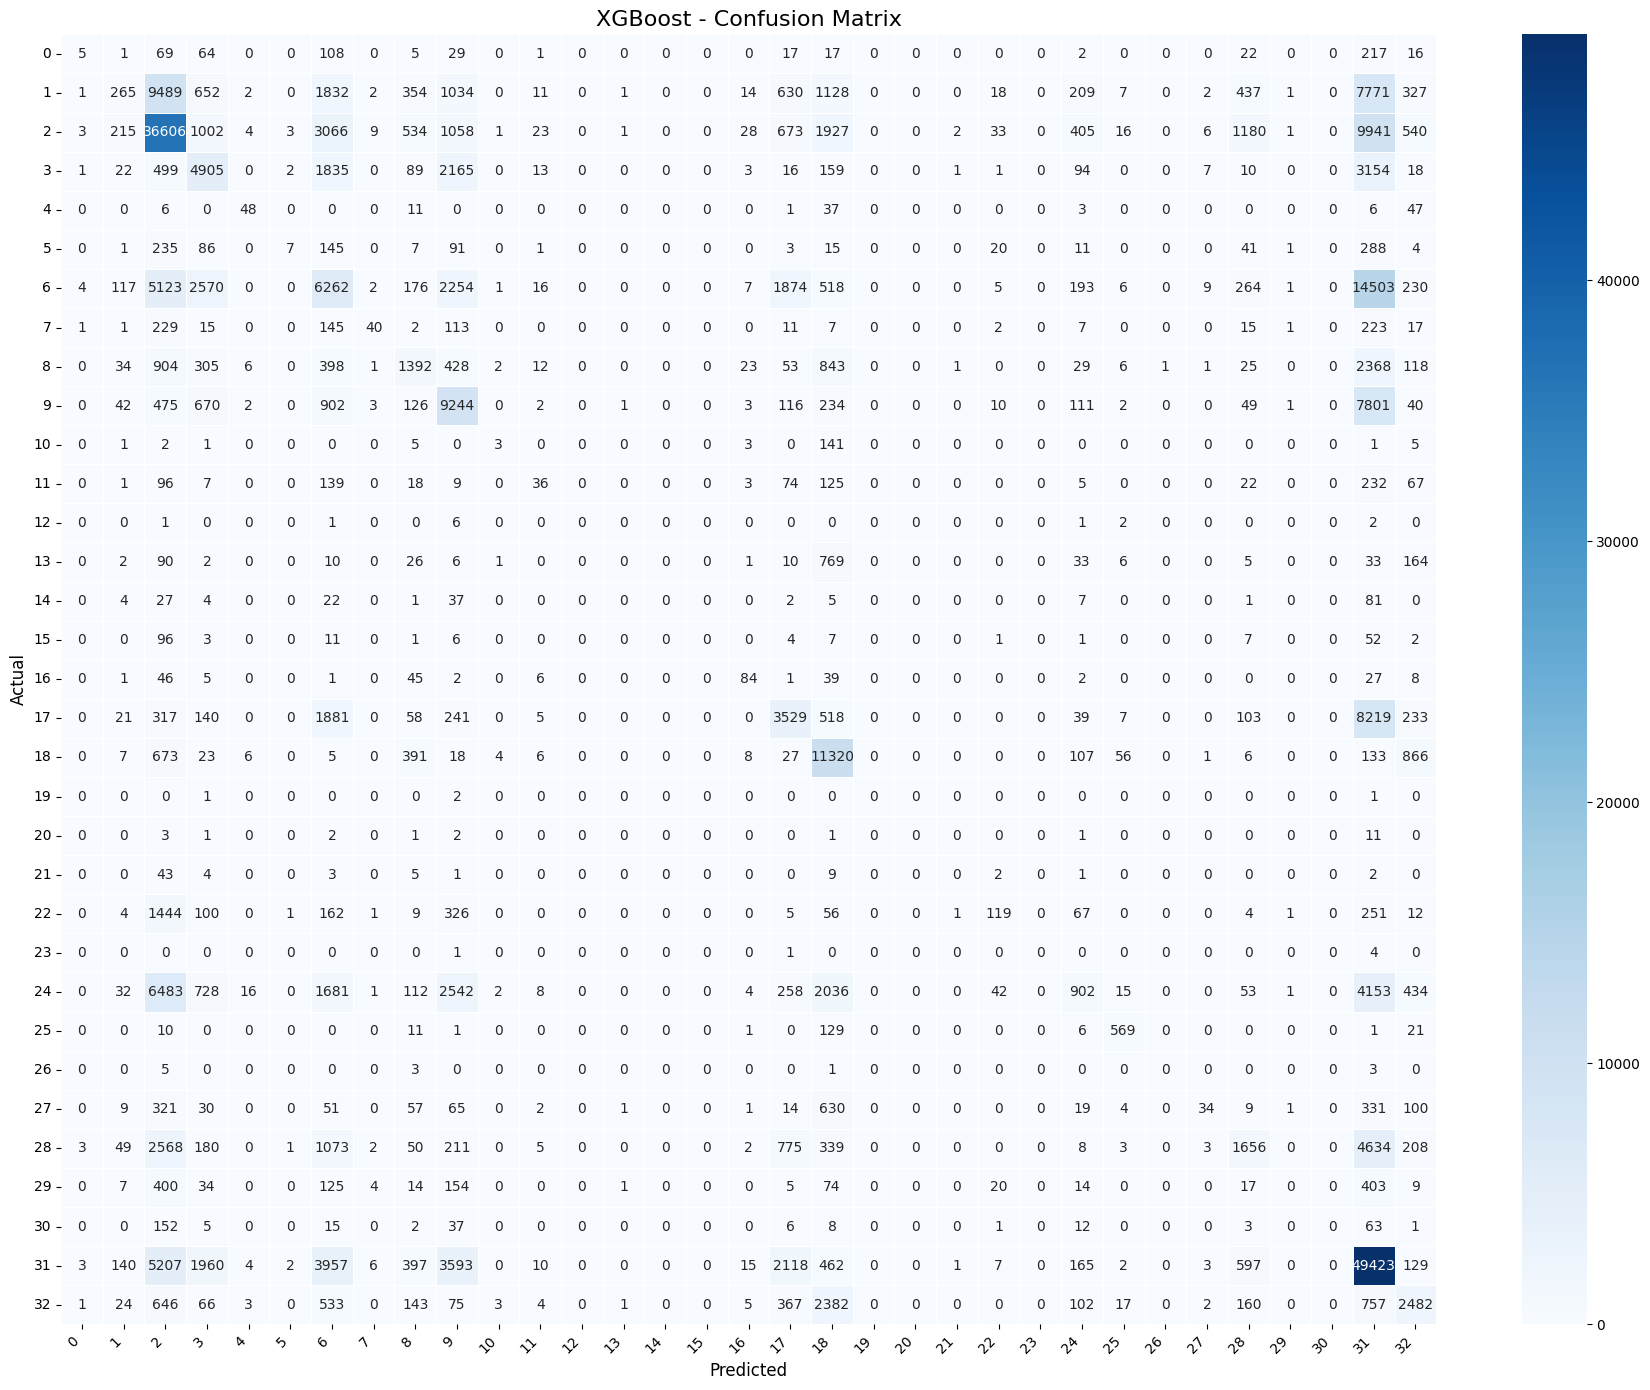


  CatBoost Evaluation
  Accuracy:            0.4195
  F1 (Macro):          0.1557
  F1 (Weighted):       0.3605
  Precision (W):       0.3827
  Recall (W):          0.4195
  Cohen Kappa:         0.3132
  Matthews CC:         0.3216

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       573
           1       0.24      0.00      0.01     24187
           2       0.50      0.65      0.56     57277
           3       0.35      0.39      0.37     12994
           4       0.48      0.30      0.37       159
           5       0.67      0.00      0.00       956
           6       0.25      0.17      0.20     34135
           7       0.51      0.04      0.07       829
           8       0.33      0.19      0.24      6950
           9       0.38      0.46      0.42     19834
          10       0.00      0.00      0.00       162
          11       0.22      0.01      0.03       834
          12       0.00      0.00

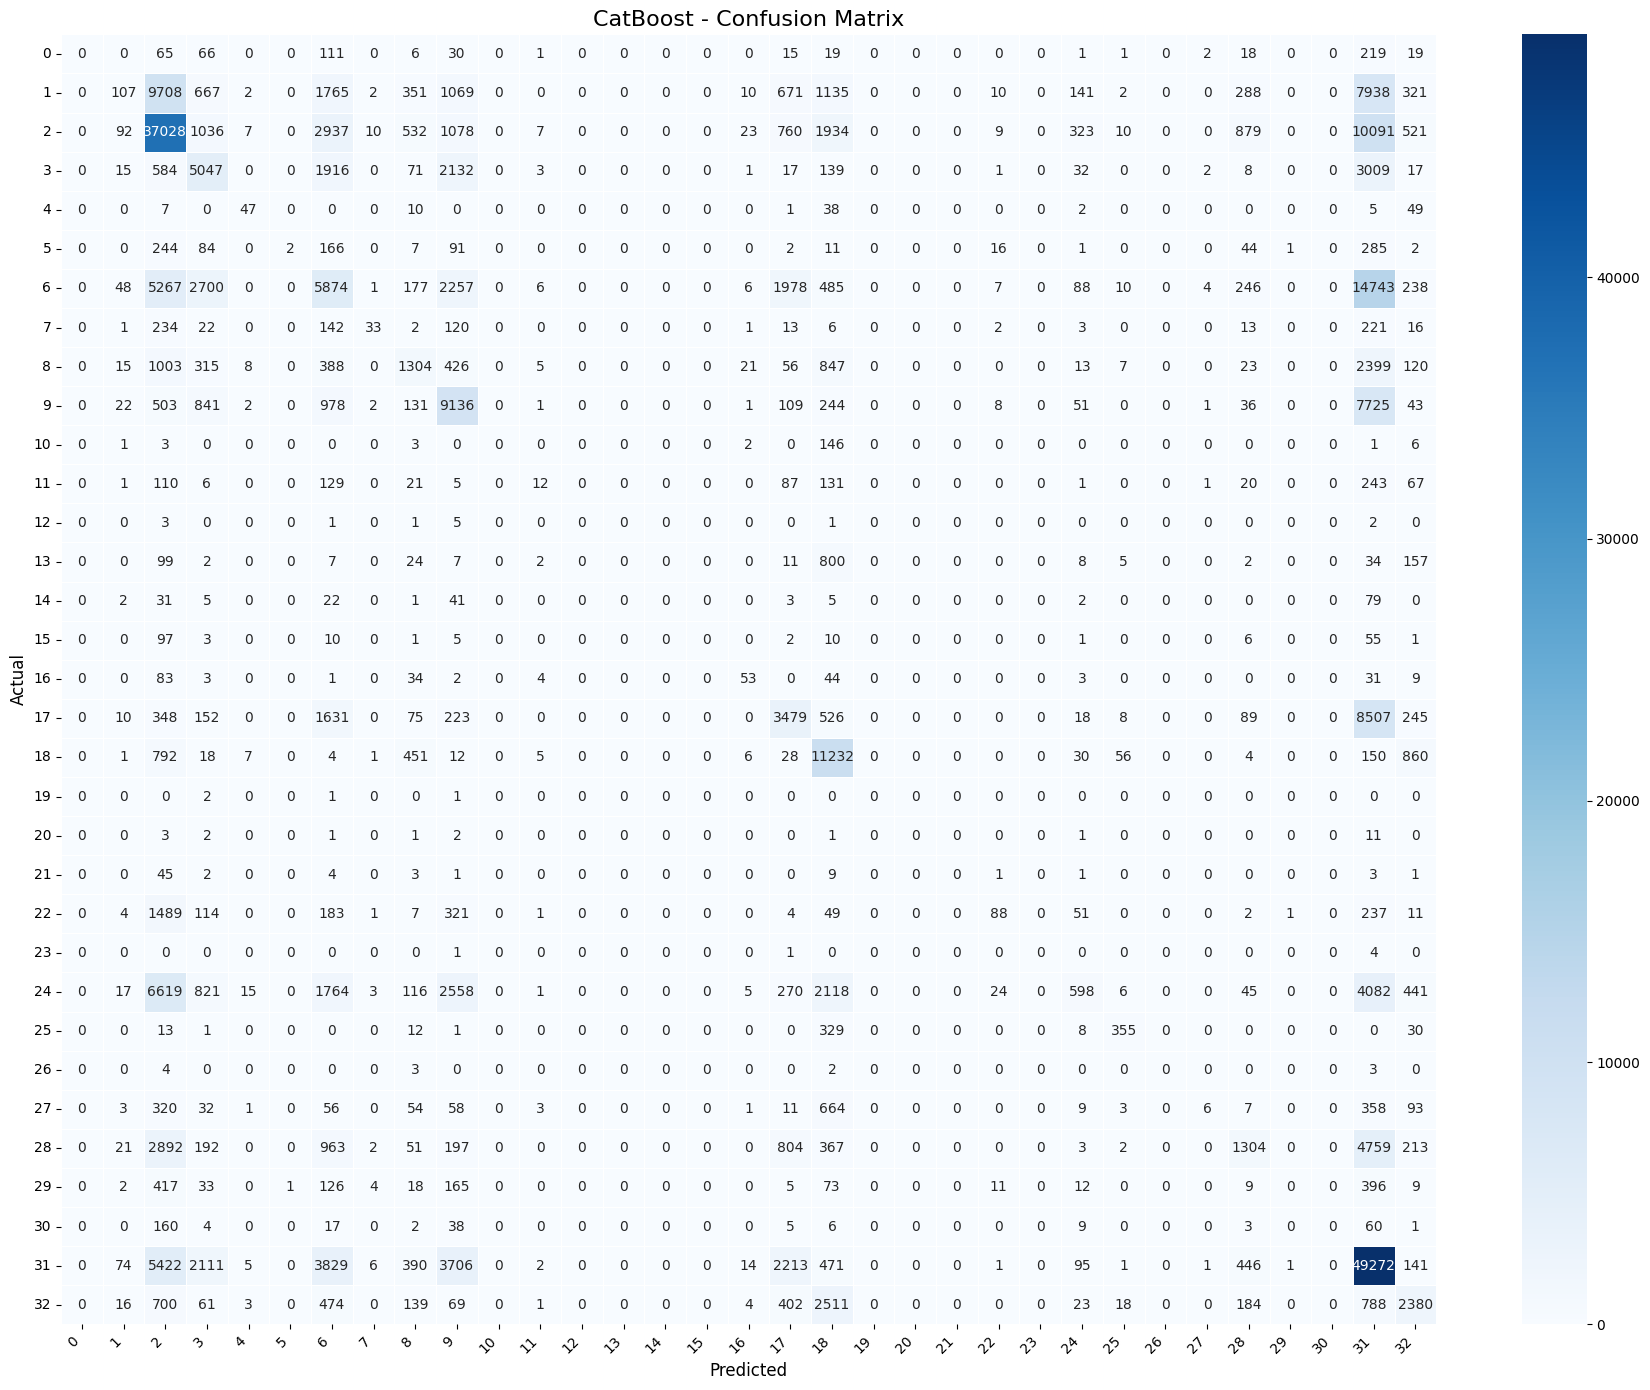


  LightGBM Evaluation
  Accuracy:            0.4243
  F1 (Macro):          0.1723
  F1 (Weighted):       0.3689
  Precision (W):       0.3905
  Recall (W):          0.4243
  Cohen Kappa:         0.3197
  Matthews CC:         0.3279

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.35      0.01      0.02       573
           1       0.27      0.01      0.02     24187
           2       0.51      0.64      0.57     57277
           3       0.35      0.38      0.37     12994
           4       0.49      0.31      0.38       159
           5       0.50      0.01      0.01       956
           6       0.26      0.18      0.21     34135
           7       0.57      0.05      0.08       829
           8       0.33      0.20      0.25      6950
           9       0.39      0.47      0.43     19834
          10       0.33      0.01      0.02       162
          11       0.22      0.03      0.06       834
          12       0.00      0.00

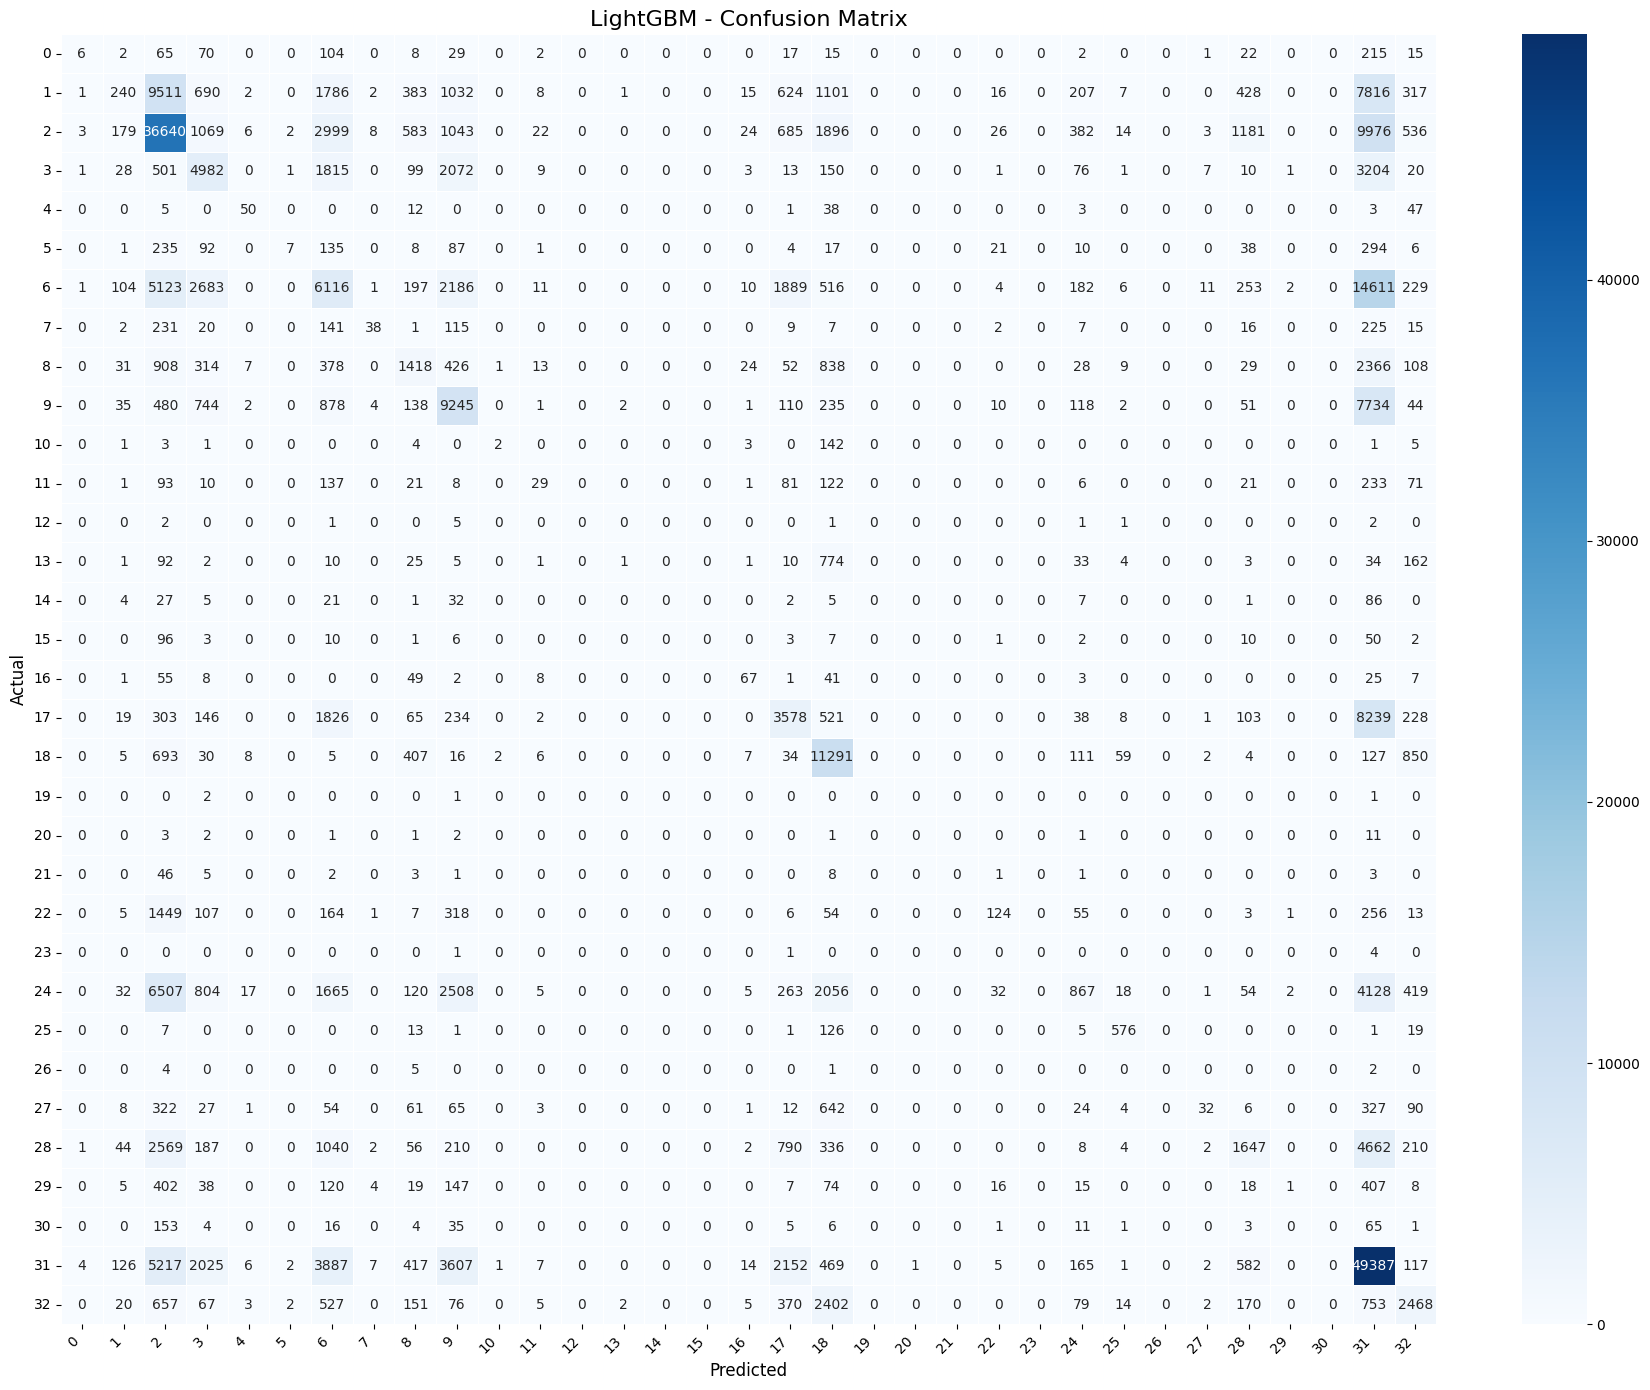

In [ ]:
class_names_str = [str(c) for c in class_names]

xgb_metrics  = evaluate_model("XGBoost",  y_test, y_pred_xgb,  class_names_str)
cat_metrics  = evaluate_model("CatBoost", y_test, y_pred_cat,  class_names_str)
lgbm_metrics = evaluate_model("LightGBM", y_test, y_pred_lgbm, class_names_str)